In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [39]:
data=pd.read_csv("person.csv")
data

,Name,Age,Gender,Salary,City
0,Ali,22.0,Male,25000.0,Jaipur
1,Ali,22.0,Male,25000.0,Jaipur
2,Sara,25.0,Female,30000.0,Delhi
3,John,NaN,Male,35000.0,Mumbai
4,Ali,22.0,Male,25000.0,Jaipur
5,Emma,150.0,Female,NaN,Delhi
6,Emma,150.0,Female,NaN,Delhi
7,Tom,28.0,Male,45000.0,NaN
8,Tom,28.0,Male,45000.0,NaN
9,Anna,24.0,Female,32000.0,Jaipur


In [3]:
# Outliers
# step 1: Calculate Q1 and Q3
Q1 = data["Age"].quantile(0.25)
Q3 = data["Age"].quantile(0.75)
print("Q1 =", Q1)
print("Q3 =", Q3)

Q1 = 24.0
Q3 = 30.0


In [4]:
# step 2: Calculate IQR
IQR=Q3-Q1
IQR

np.float64(6.0)

In [5]:
# step 3: Calculate Lower and Upper Limits
lower_limit = Q1-1.5 * IQR
lower_limit

np.float64(15.0)

In [6]:
upper_limit = Q3 + 1.5 * IQR
upper_limit

np.float64(39.0)

In [7]:
# detect outliers
age_outliers = data[
    (data["Age"]< lower_limit) | (data["Age"]> upper_limit)
]
age_outliers

,Name,Age,Gender,Salary,City
5,Emma,150.0,Female,NaN,Delhi
6,Emma,150.0,Female,NaN,Delhi
10,David,-5.0,Male,28000.0,Mumbai
24,Vikas,120.0,Male,250000.0,Jaipur


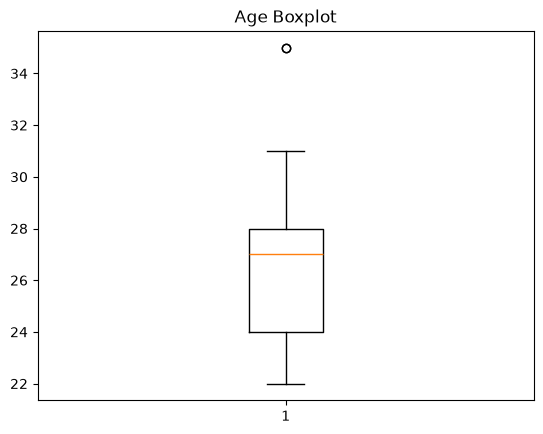

In [38]:
# Visualize Outliers Using Boxplot
## Age
import matplotlib.pyplot as plt
plt.boxplot(data["Age"])
plt.title("Age Boxplot")
plt.show()

In [12]:
data.groupby("Gender")["Salary"].mean()


Gender
Female    40800.000000
Male      56071.428571
Name: Salary, dtype: float64

In [14]:
data.groupby("City")["Salary"].mean()


City
Delhi     48285.714286
Jaipur    58555.555556
Mumbai    39666.666667
Name: Salary, dtype: float64

In [17]:
data.groupby("City")["Name"].count()


City
Delhi     9
Jaipur    9
Mumbai    6
Name: Name, dtype: int64

In [19]:
data["Gender"].value_counts()

Gender
Male      14
Female    12
Name: count, dtype: int64

In [20]:
data["City"].value_counts()

City
Jaipur    9
Delhi     9
Mumbai    6
Name: count, dtype: int64

In [8]:
print(data.shape)


(26, 5)


In [9]:
data = data[
    (data["Age"] >= lower_limit) &
    (data["Age"] <= upper_limit)
]

In [10]:
data.shape

(21, 5)

In [11]:
data[data["Salary"]>50000]

,Name,Age,Gender,Salary,City
14,Neha,31.0,Female,52000.0,Delhi
17,Arjun,35.0,Male,65000.0,Delhi
18,Arjun,35.0,Male,65000.0,Delhi
21,Rohit,30.0,Male,55000.0,Mumbai


In [12]:
data[data["Gender"] == "Female"]

,Name,Age,Gender,Salary,City
2,Sara,25.0,Female,30000.0,Delhi
9,Anna,24.0,Female,32000.0,Jaipur
12,Priya,26.0,Female,42000.0,Jaipur
14,Neha,31.0,Female,52000.0,Delhi
16,Meera,23.0,Female,31000.0,Mumbai
19,Simran,28.0,Female,47000.0,Jaipur
20,Simran,28.0,Female,47000.0,Jaipur
22,Kavya,27.0,Female,44000.0,Delhi
23,Kavya,27.0,Female,44000.0,Delhi
25,Pooja,27.0,Female,39000.0,Mumbai


In [14]:
data[data["City"] == "Jaipur"]

,Name,Age,Gender,Salary,City
0,Ali,22.0,Male,25000.0,Jaipur
1,Ali,22.0,Male,25000.0,Jaipur
4,Ali,22.0,Male,25000.0,Jaipur
9,Anna,24.0,Female,32000.0,Jaipur
12,Priya,26.0,Female,42000.0,Jaipur
15,Karan,24.0,Male,34000.0,Jaipur
19,Simran,28.0,Female,47000.0,Jaipur
20,Simran,28.0,Female,47000.0,Jaipur


In [15]:
data.sort_values("Salary")

,Name,Age,Gender,Salary,City
0,Ali,22.0,Male,25000.0,Jaipur
1,Ali,22.0,Male,25000.0,Jaipur
4,Ali,22.0,Male,25000.0,Jaipur
2,Sara,25.0,Female,30000.0,Delhi
16,Meera,23.0,Female,31000.0,Mumbai
9,Anna,24.0,Female,32000.0,Jaipur
15,Karan,24.0,Male,34000.0,Jaipur
11,Aman,27.0,Male,38000.0,Delhi
25,Pooja,27.0,Female,39000.0,Mumbai
12,Priya,26.0,Female,42000.0,Jaipur


In [17]:
data.sort_values("Salary", ascending=False)

,Name,Age,Gender,Salary,City
18,Arjun,35.0,Male,65000.0,Delhi
17,Arjun,35.0,Male,65000.0,Delhi
21,Rohit,30.0,Male,55000.0,Mumbai
14,Neha,31.0,Female,52000.0,Delhi
13,Rahul,29.0,Male,50000.0,Mumbai
20,Simran,28.0,Female,47000.0,Jaipur
19,Simran,28.0,Female,47000.0,Jaipur
7,Tom,28.0,Male,45000.0,NaN
8,Tom,28.0,Male,45000.0,NaN
23,Kavya,27.0,Female,44000.0,Delhi


In [18]:
data.sort_values("Age", ascending=False)

,Name,Age,Gender,Salary,City
18,Arjun,35.0,Male,65000.0,Delhi
17,Arjun,35.0,Male,65000.0,Delhi
14,Neha,31.0,Female,52000.0,Delhi
21,Rohit,30.0,Male,55000.0,Mumbai
13,Rahul,29.0,Male,50000.0,Mumbai
7,Tom,28.0,Male,45000.0,NaN
19,Simran,28.0,Female,47000.0,Jaipur
8,Tom,28.0,Male,45000.0,NaN
20,Simran,28.0,Female,47000.0,Jaipur
11,Aman,27.0,Male,38000.0,Delhi


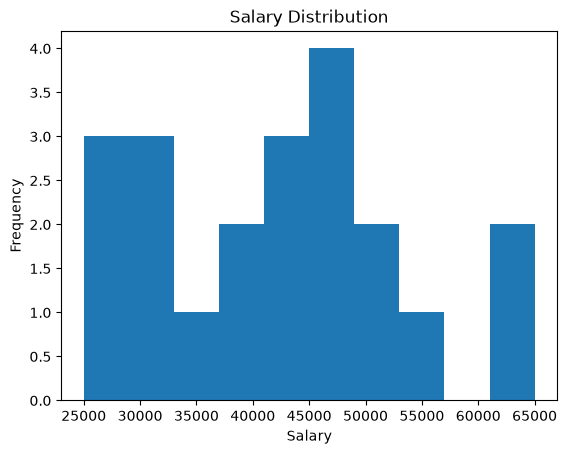

In [19]:
# Histogram
## Salary Distribution
plt.hist(data["Salary"])
plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Frequency")
plt.show()

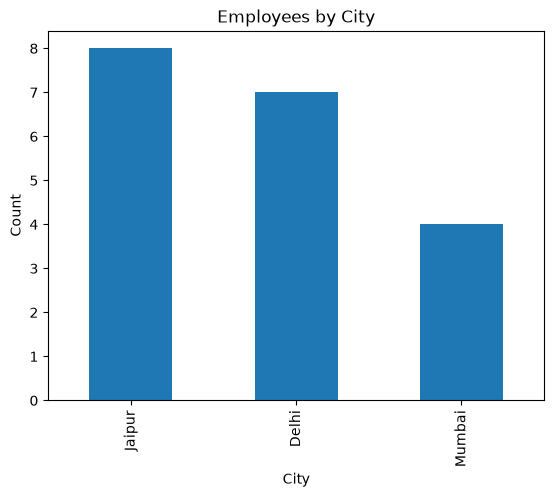

In [ ]:
# bar chart
data["City"].value_counts().plot(kind="bar")
plt.title("Employees by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

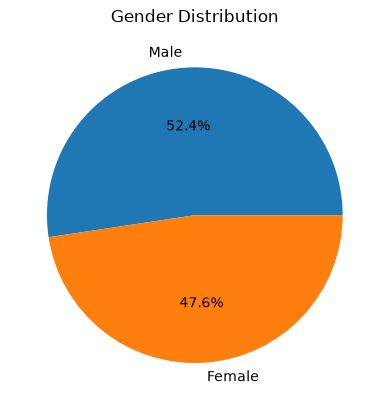

In [25]:
# Pie Chart
## Gender Distribution
data["Gender"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.title("Gender Distribution")
plt.show()

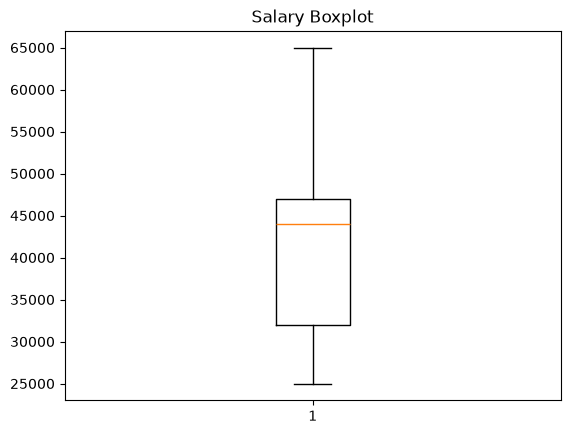

In [31]:
# Box Plot
## Salary Outliers
plt.boxplot(data["Salary"])
plt.title("Salary Boxplot")
plt.show()

Text(0, 0.5, 'Salary')

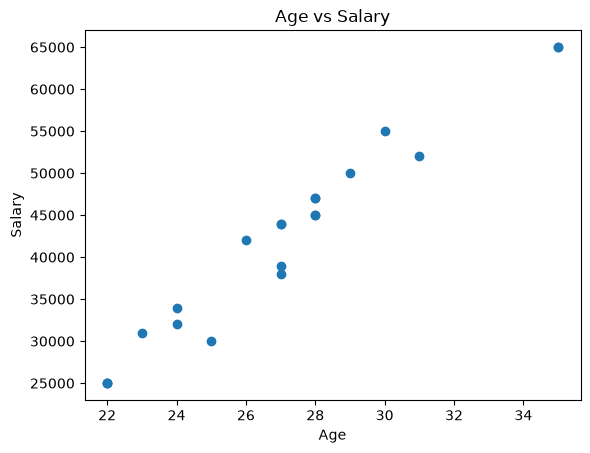

In [35]:
# Scatter Plot
## Age vs Salary
plt.scatter(
    data["Age"],
    data["Salary"]
)

plt.title("Age vs Salary")
plt.xlabel("Age")
plt.ylabel("Salary")

In [36]:
# Complete EDA Report
data.describe()

,Age,Salary
count,21.000000,21.000000
mean,27.047619,41904.761905
std,3.707778,11806.374388
min,22.000000,25000.000000
25%,24.000000,32000.000000
50%,27.000000,44000.000000
75%,28.000000,47000.000000
max,35.000000,65000.000000


In [37]:
len(data)

21